Available columns in session 1: ['Unnamed: 0', 'Experiment', 'v1_mean', 'v2_mean', 'zr_mean', 'a_mean_s1', 'ndt_mean_s1', 'sndt_mean', 'alpha_mean', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_error', 'error_array', 'RT_Cor_arr', 'ID', 'Task', 'Session', 'alpha_shifted', 'alpha_clipped', 'alpha_arcsin', 'alpha_boxcox_after_arcsin_s1', 'accuracy_arcsin', 'accuracy_percentage_boxcox_after_arcsin']
Available columns in session 2: ['Unnamed: 0', 'Experiment', 'v1_mean', 'v2_mean', 'zr_mean', 'a_mean_s2', 'ndt_mean_s2', 'sndt_mean', 'alpha_mean', 'accuracy_percentage', 'mean_log_rt', 'RT_mean_correct_error', 'mean_correct', 'mean_error', 'error_array', 'RT_Cor_arr', 'ID', 'Task', 'Session', 'alpha_shifted', 'alpha_clipped', 'alpha_arcsin', 'alpha_boxcox_after_arcsin_s2', 'accuracy_arcsin', 'accuracy_percentage_boxcox_after_arcsin']
Using identifier column: ID
Data loaded successfully. Number of participants: 104
Analyzing dataset: LDT Model 1

Data-d

k,Raw MI (bits),p (Raw MI),CMI All (bits),p (All),Ret All (%),CMI Thresh (bits),p (Thresh),Ret Thresh (%),CMI NDT (bits),p (NDT),Ret NDT (%)
3,0.628,0.0010,0.136,0.0010,21.7,0.238,0.0010,37.9,0.115,0.0080,18.2
5,0.638,0.0010,0.032,0.0020,5.1,0.207,0.0010,32.4,0.255,0.0010,40.0
7,0.540,0.0010,0.008,0.0020,1.6,0.130,0.0010,24.0,0.239,0.0010,44.2
10,0.477,0.0010,0.003,0.0020,0.6,0.129,0.0010,27.0,0.202,0.0010,42.4



Generating Plots (calling methods from KSG_MI_First.py)


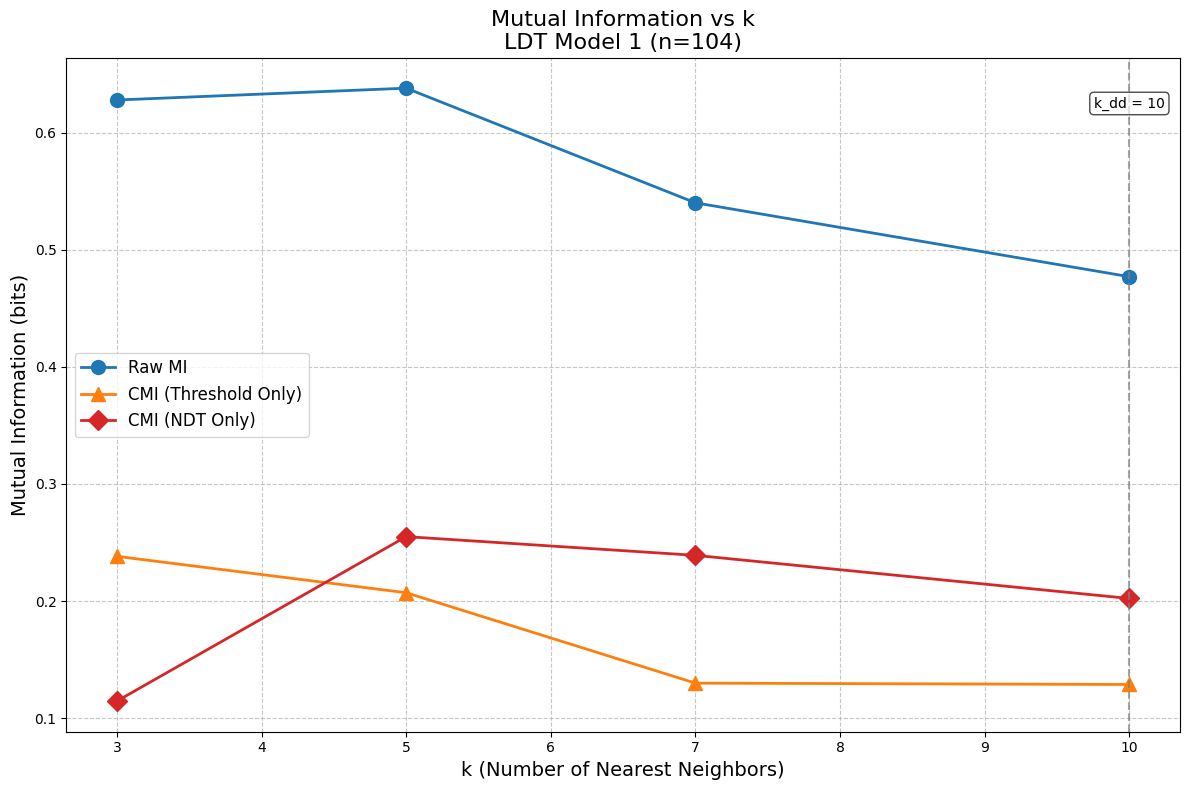

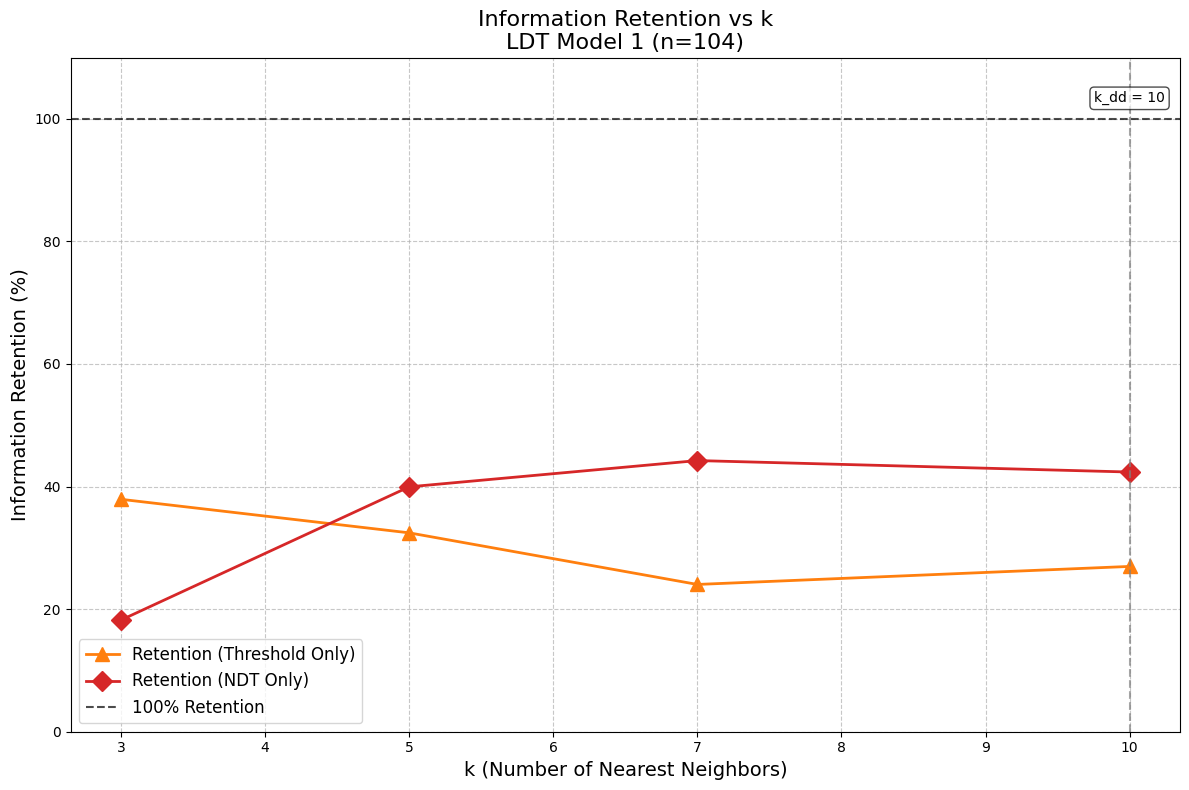

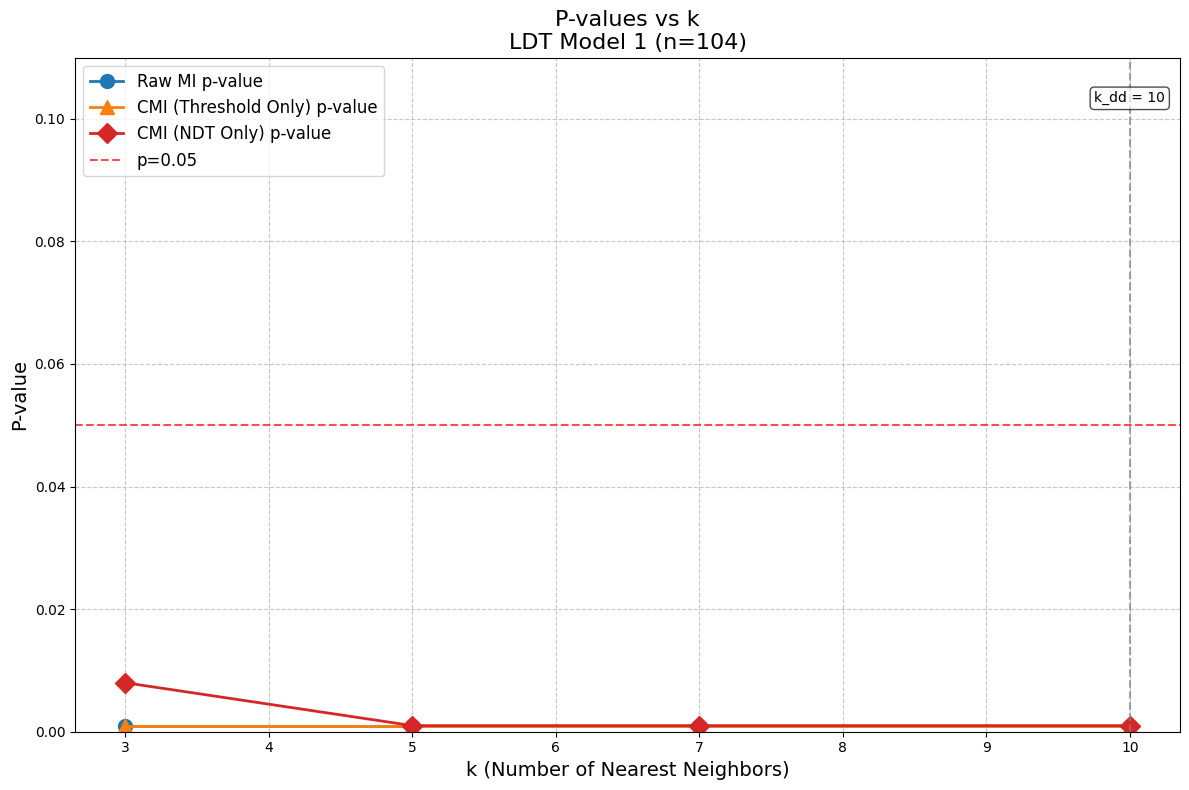

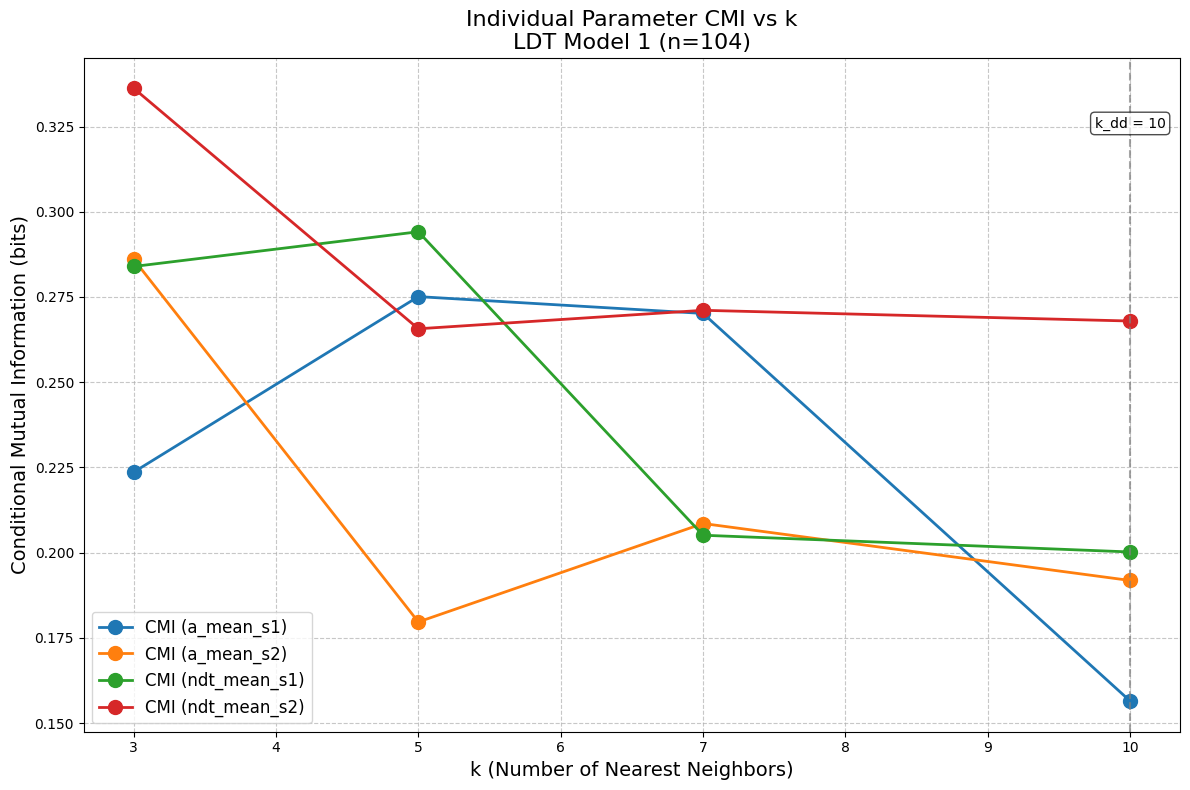

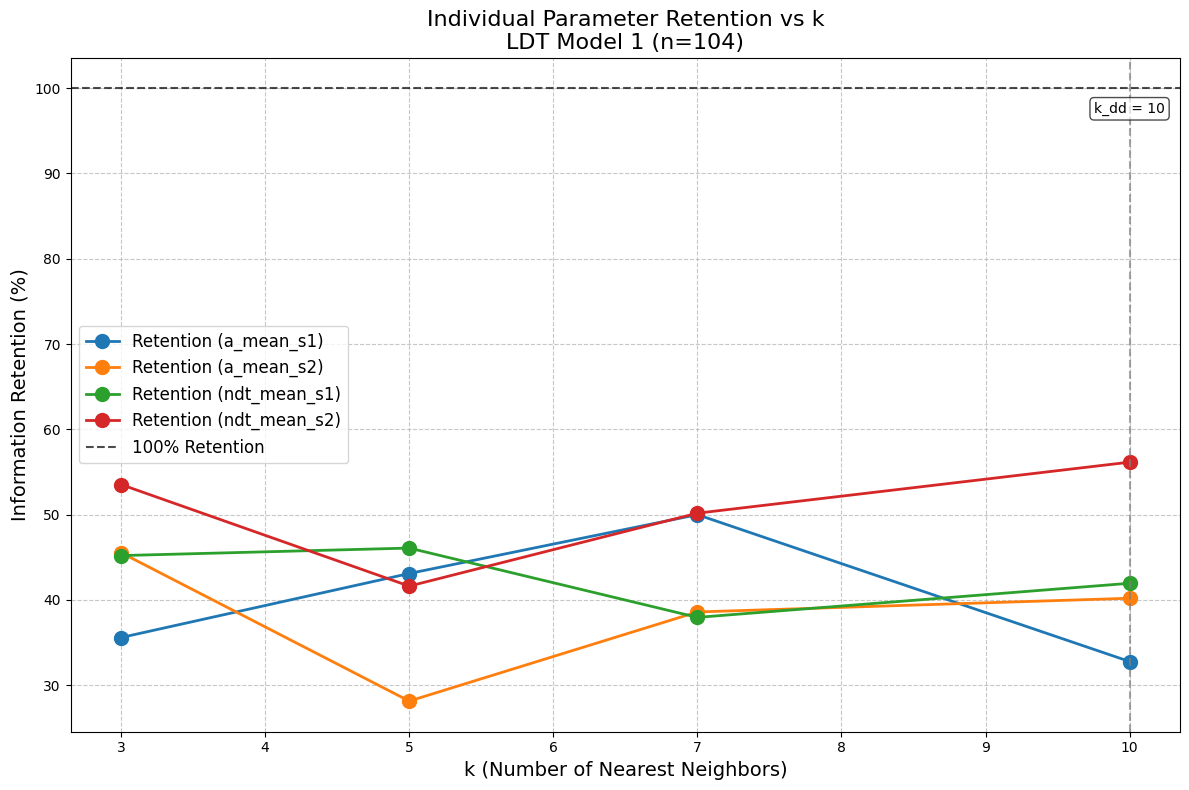

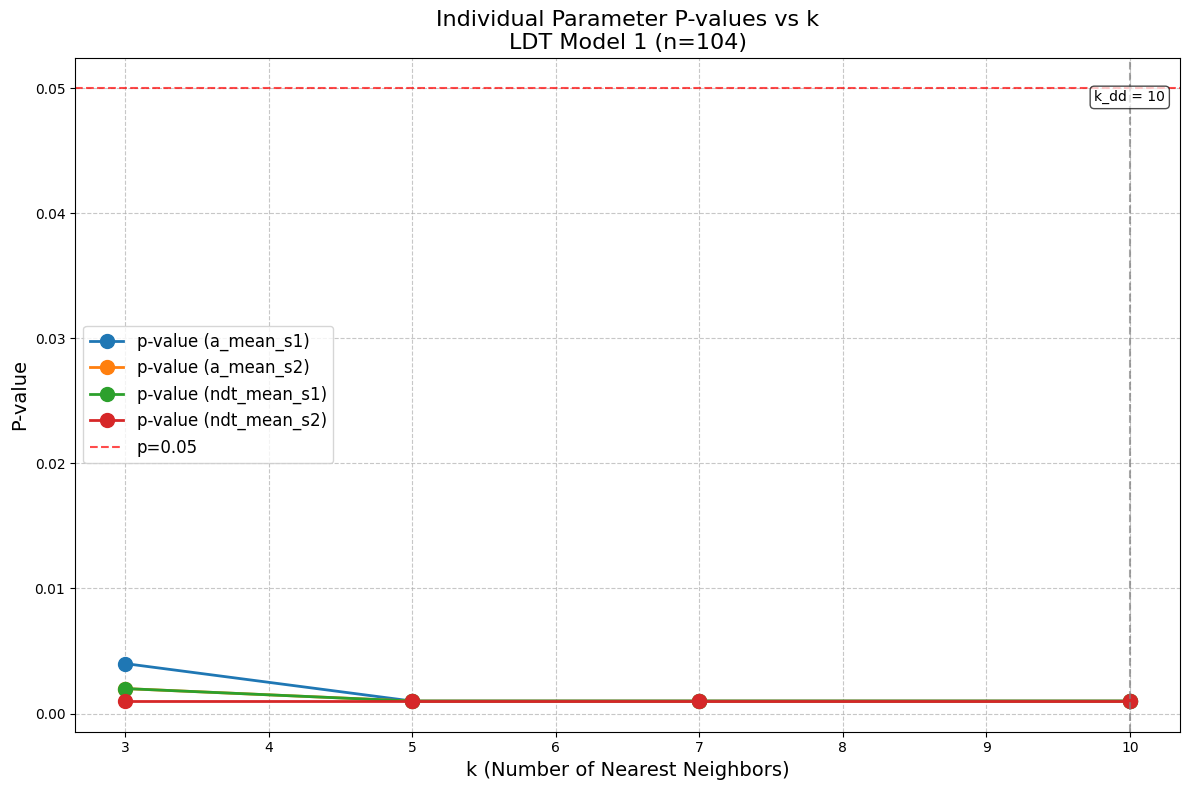


Plot generation finished. Plots should appear above.

Comprehensive Text Results

--- Results for k=3  ---
Raw MI: 0.6281 bits (p=0.0010)
CMI (All Controls): 0.1361 bits (p=0.0010), Retention: 21.7%
CMI (Threshold Only): 0.2382 bits (p=0.0010), Retention: 37.9%
CMI (NDT Only): 0.1145 bits (p=0.0080), Retention: 18.2%

Individual Parameter Effects:
  a_mean_s1: CMI=0.2236 bits (p=0.0040), Retention=35.6%
  a_mean_s2: CMI=0.2861 bits (p=0.0020), Retention=45.5%
  ndt_mean_s1: CMI=0.2839 bits (p=0.0020), Retention=45.2%
  ndt_mean_s2: CMI=0.3363 bits (p=0.0010), Retention=53.5%

--- Results for k=5  ---
Raw MI: 0.6382 bits (p=0.0010)
CMI (All Controls): 0.0324 bits (p=0.0020), Retention: 5.1%
CMI (Threshold Only): 0.2071 bits (p=0.0010), Retention: 32.4%
CMI (NDT Only): 0.2550 bits (p=0.0010), Retention: 40.0%

Individual Parameter Effects:
  a_mean_s1: CMI=0.2751 bits (p=0.0010), Retention=43.1%
  a_mean_s2: CMI=0.1797 bits (p=0.0010), Retention=28.1%
  ndt_mean_s1: CMI=0.2941 bits (p=0

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display, HTML

# --- Import from your script ---
# Make sure KSG_MI_First.py is in the same directory or accessible
try:
    # We might need to reload the module if it was changed since the kernel started
    import importlib
    import KSG_MI_First
    importlib.reload(KSG_MI_First) # Reload to get the changes with plt.show()
    from KSG_MI_First import KSGMutualInformationAnalyzer, load_and_merge
except ImportError:
    print("Error: Could not import from KSG_MI_First.py.")
    print("Make sure the file is in the same directory as the notebook or in the Python path.")
    # You might need to add the directory to the path if it's elsewhere:
    # import sys
    # sys.path.append('/path/to/your/script/directory')
    # from KSG_MI_First import KSGMutualInformationAnalyzer, load_and_merge

# --- Configuration ---
# <<< IMPORTANT: UPDATE THESE PATHS >>>
session1_path = 'Model1 LDT RMT/ldt_session_1_data_transformed.csv'
session2_path = 'Model1 LDT RMT/ldt_session_2_data_transformed.csv'
dataset_name_override = "LDT Model 1" # Optional: Or set to None to use automatic naming

# Analysis parameters
feature = 'alpha_s1'
target = 'alpha_s2'
control_vars = ['a_mean_s1', 'a_mean_s2', 'ndt_mean_s1', 'ndt_mean_s2']
n_permutations = 1000 # Lower for faster notebook execution, increase for final results (e.g., 5000)

# --- Load and Prepare Data ---
try:
    df_merged = load_and_merge(session1_path, session2_path)
    print(f"Data loaded successfully. Number of participants: {len(df_merged)}")

    # --- Initialize Analyzer ---
    analyzer = KSGMutualInformationAnalyzer(df_merged)

    # Determine dataset name
    dataset_name = dataset_name_override
    if dataset_name is None:
        dataset_name = analyzer.get_dataset_name(session1_path)
    print(f"Analyzing dataset: {dataset_name}")

    # --- Run Analysis ---
    results = {}
    individual_results = {}

    # Calculate data-driven k value
    k_data_driven = int(np.sqrt(len(df_merged)))
    print(f"\nData-driven k value (sqrt(N)): {k_data_driven}")

    # Define k values to test (including data-driven k)
    k_values = [3, 5, 7, 10, k_data_driven]
    k_values = sorted(list(set(k_values))) # Remove duplicates and sort
    print(f"Testing k values: {k_values}")

    # Run analysis for each k
    for k in k_values:
        print(f"\nAnalyzing with k={k}...")
        # Reliability analysis (Raw MI, CMI All/Thresh/NDT)
        results[k] = analyzer.analyze_alpha_reliability(
            feature=feature,
            target=target,
            control_vars=control_vars,
            k=k,
            n_permutations=n_permutations
        )

        # Individual parameter analysis (CMI for each control var)
        individual_results[k] = analyzer.analyze_individual_parameters(
            feature=feature,
            target=target,
            control_vars=control_vars,
            k=k,
            n_permutations=n_permutations
        )
    print("\nAnalysis complete.")

    # --- Display Summary Table ---
    print("\n" + "="*80)
    print("Summary Table")
    print("="*80)
    summary_data = []
    for k in k_values:
        res_k = results[k]
        row = {
            'k': k,
            'Raw MI (bits)': f"{res_k['ksg_mi'][0]:.3f}",
            'p (Raw MI)': f"{res_k['ksg_mi'][1]:.4f}",
            'CMI All (bits)': f"{res_k.get('cond_mi_all', np.nan):.3f}",
            'p (All)': f"{res_k.get('p_value_all', np.nan):.4f}",
            'Ret All (%)': f"{res_k.get('retention_all', np.nan):.1f}",
            'CMI Thresh (bits)': f"{res_k.get('cond_mi_thresh', np.nan):.3f}",
            'p (Thresh)': f"{res_k.get('p_value_thresh', np.nan):.4f}",
            'Ret Thresh (%)': f"{res_k.get('retention_thresh', np.nan):.1f}",
            'CMI NDT (bits)': f"{res_k.get('cond_mi_ndt', np.nan):.3f}",
            'p (NDT)': f"{res_k.get('p_value_ndt', np.nan):.4f}",
            'Ret NDT (%)': f"{res_k.get('retention_ndt', np.nan):.1f}",
        }
        summary_data.append(row)

    df_summary = pd.DataFrame(summary_data)

   
    # --- ADD THIS LINE TO SAVE CSV ---
    csv_save_path = f"summary_results_{dataset_name.replace(' ', '_')}.csv"
    df_summary.to_csv(csv_save_path, index=False)
    print(f"Summary table saved to: {csv_save_path}")

    display(HTML(df_summary.to_html(index=False, na_rep='NaN')))


    # --- Generate Plots Inline by Calling Class Methods ---
    print("\n" + "="*80)
    print("Generating Plots (calling methods from KSG_MI_First.py)")
    print("="*80)

    # Call the main results plotting method
    # Pass one result dict for single point info, and all results for line plots
    analyzer.plot_results(
        results=results[k_values[-1]], # Pass results for one k (e.g., last one)
        all_k_results=results,
        feature=feature,
        target=target,
        session1_path=session1_path, # For naming
        dataset_name=dataset_name
    )

    # Call the individual parameter plotting method
    analyzer.plot_individual_parameter_effects(
        all_k_results=individual_results, # Pass the individual results dict
        feature=feature,
        target=target,
        control_vars=control_vars,
        session1_path=session1_path, # For naming
        dataset_name=dataset_name
    )

    print("\nPlot generation finished. Plots should appear above.")


    # --- Print Comprehensive Text Results ---
    print("\n" + "="*80)
    print("Comprehensive Text Results")
    print("="*80)
    for k in k_values:
        print(f"\n--- Results for k={k} {'(Data-driven)' if k == k_data_driven else ''} ---")
        res_k = results[k]
        res_indiv_k = individual_results[k]

        # Raw MI
        print(f"Raw MI: {res_k['ksg_mi'][0]:.4f} bits (p={res_k['ksg_mi'][1]:.4f})")

        # Grouped CMI
        if 'cond_mi_all' in res_k:
            print(f"CMI (All Controls): {res_k['cond_mi_all']:.4f} bits (p={res_k['p_value_all']:.4f}), Retention: {res_k['retention_all']:.1f}%")
        if 'cond_mi_thresh' in res_k:
            print(f"CMI (Threshold Only): {res_k['cond_mi_thresh']:.4f} bits (p={res_k['p_value_thresh']:.4f}), Retention: {res_k['retention_thresh']:.1f}%")
        if 'cond_mi_ndt' in res_k:
            print(f"CMI (NDT Only): {res_k['cond_mi_ndt']:.4f} bits (p={res_k['p_value_ndt']:.4f}), Retention: {res_k['retention_ndt']:.1f}%")

        # Individual CMI
        print("\nIndividual Parameter Effects:")
        for var in control_vars:
            if var in res_indiv_k:
                indiv_res = res_indiv_k[var]
                print(f"  {var}: CMI={indiv_res['cmi']:.4f} bits (p={indiv_res['p_value']:.4f}), Retention={indiv_res['retention']:.1f}%")
            else:
                print(f"  {var}: Not calculated")


except FileNotFoundError:
    print(f"Error: One or both input files not found.")
    print(f"Checked paths: '{session1_path}', '{session2_path}'")
    print("Please ensure the file paths at the top of the cell are correct.")
except ImportError:
     # Error message already printed in the import block
     pass
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    import traceback
    traceback.print_exc()